Requirements

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import json

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')

Dataset

In [4]:
df = pd.read_csv(r'C:\Users\manas\Downloads\Code\IRIS\AI\dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget classes:\n{df['ProblemDetected'].value_counts()}")

Dataset shape: (5000, 17)

Target classes:
ProblemDetected
Normal          1400
Disk_Failure    1003
Memory_Leak     1003
Overheating      797
Power_Issue      797
Name: count, dtype: int64


In [5]:
df = df.drop(columns=['DeviceID'])

In [6]:
df = pd.get_dummies(df, columns=['Brand', 'OS'], drop_first=True)

In [7]:
X = df.drop(columns=['ProblemDetected'])
y = df['ProblemDetected']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Label mapping: {'Disk_Failure': np.int64(0), 'Memory_Leak': np.int64(1), 'Normal': np.int64(2), 'Overheating': np.int64(3), 'Power_Issue': np.int64(4)}

Train size: 3500 | Test size: 1500


Model Training

In [8]:
# Define Models
models = {
    "Random Forest":       RandomForestClassifier(n_estimators=200,  random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": Pipeline([('scaler', StandardScaler()),
                                     ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    "SVM":                 Pipeline([('scaler', StandardScaler()),
                                     ('svm', SVC(kernel='rbf', probability=True, random_state=42))]),
    "KNN":                 Pipeline([('scaler', StandardScaler()),
                                     ('knn', KNeighborsClassifier(n_neighbors=7))]),
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("MODEL COMPARISON")

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_acc  = accuracy_score(y_test, y_pred)
    test_f1   = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'model':    model,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_acc': test_acc,
        'test_f1':  test_f1,
        'y_pred':   y_pred,
    }
    print(f"\n{name}")
    print(f"  CV Accuracy : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(f"  Test Acc    : {test_acc:.4f}")
    print(f"  Test F1     : {test_f1:.4f}")

MODEL COMPARISON

Random Forest
  CV Accuracy : 0.9794 +/- 0.0051
  Test Acc    : 0.9860
  Test F1     : 0.9860

Gradient Boosting
  CV Accuracy : 0.9760 +/- 0.0057
  Test Acc    : 0.9847
  Test F1     : 0.9847

Logistic Regression
  CV Accuracy : 0.9766 +/- 0.0062
  Test Acc    : 0.9807
  Test F1     : 0.9807

SVM
  CV Accuracy : 0.9791 +/- 0.0044
  Test Acc    : 0.9833
  Test F1     : 0.9833

KNN
  CV Accuracy : 0.9694 +/- 0.0058
  Test Acc    : 0.9747
  Test F1     : 0.9746


Best Model

In [9]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best      = results[best_name]

print(f"BEST MODEL: {best_name}  (Test Accuracy: {best['test_acc']:.4f})")
print("\nDetailed Classification Report:")
print(classification_report(y_test, best['y_pred'], target_names=le.classes_))

BEST MODEL: Random Forest  (Test Accuracy: 0.9860)

Detailed Classification Report:
              precision    recall  f1-score   support

Disk_Failure       0.99      0.99      0.99       301
 Memory_Leak       0.98      0.98      0.98       301
      Normal       0.99      0.99      0.99       420
 Overheating       0.98      0.99      0.99       239
 Power_Issue       0.99      0.98      0.99       239

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



Feature Importance

In [10]:
feat_imp = None
best_model = best['model']
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(feat_imp)
else:
    print("Feature importance not available")

Memory_Used_Pct       0.172263
Disk_Health_Pct       0.129962
System_Voltage_V      0.116497
Battery_Health_Pct    0.091496
Disk_Read_MBps        0.088317
CPU_Temperature_C     0.080483
GPU_Temperature_C     0.079528
Fan_Speed_RPM         0.072141
Disk_Write_MBps       0.058461
System_Uptime_Hrs     0.050021
CPU_Load_Pct          0.041949
DeviceAgeYears        0.006513
Network_Usage_MBps    0.006055
OS_Windows 11         0.000842
OS_Windows 10         0.000824
Brand_Asus            0.000745
Brand_Dell            0.000728
Brand_HP              0.000694
OS_macOS              0.000654
Brand_MSI             0.000652
Brand_Apple           0.000595
Brand_Lenovo          0.000581
dtype: float64


Graphs

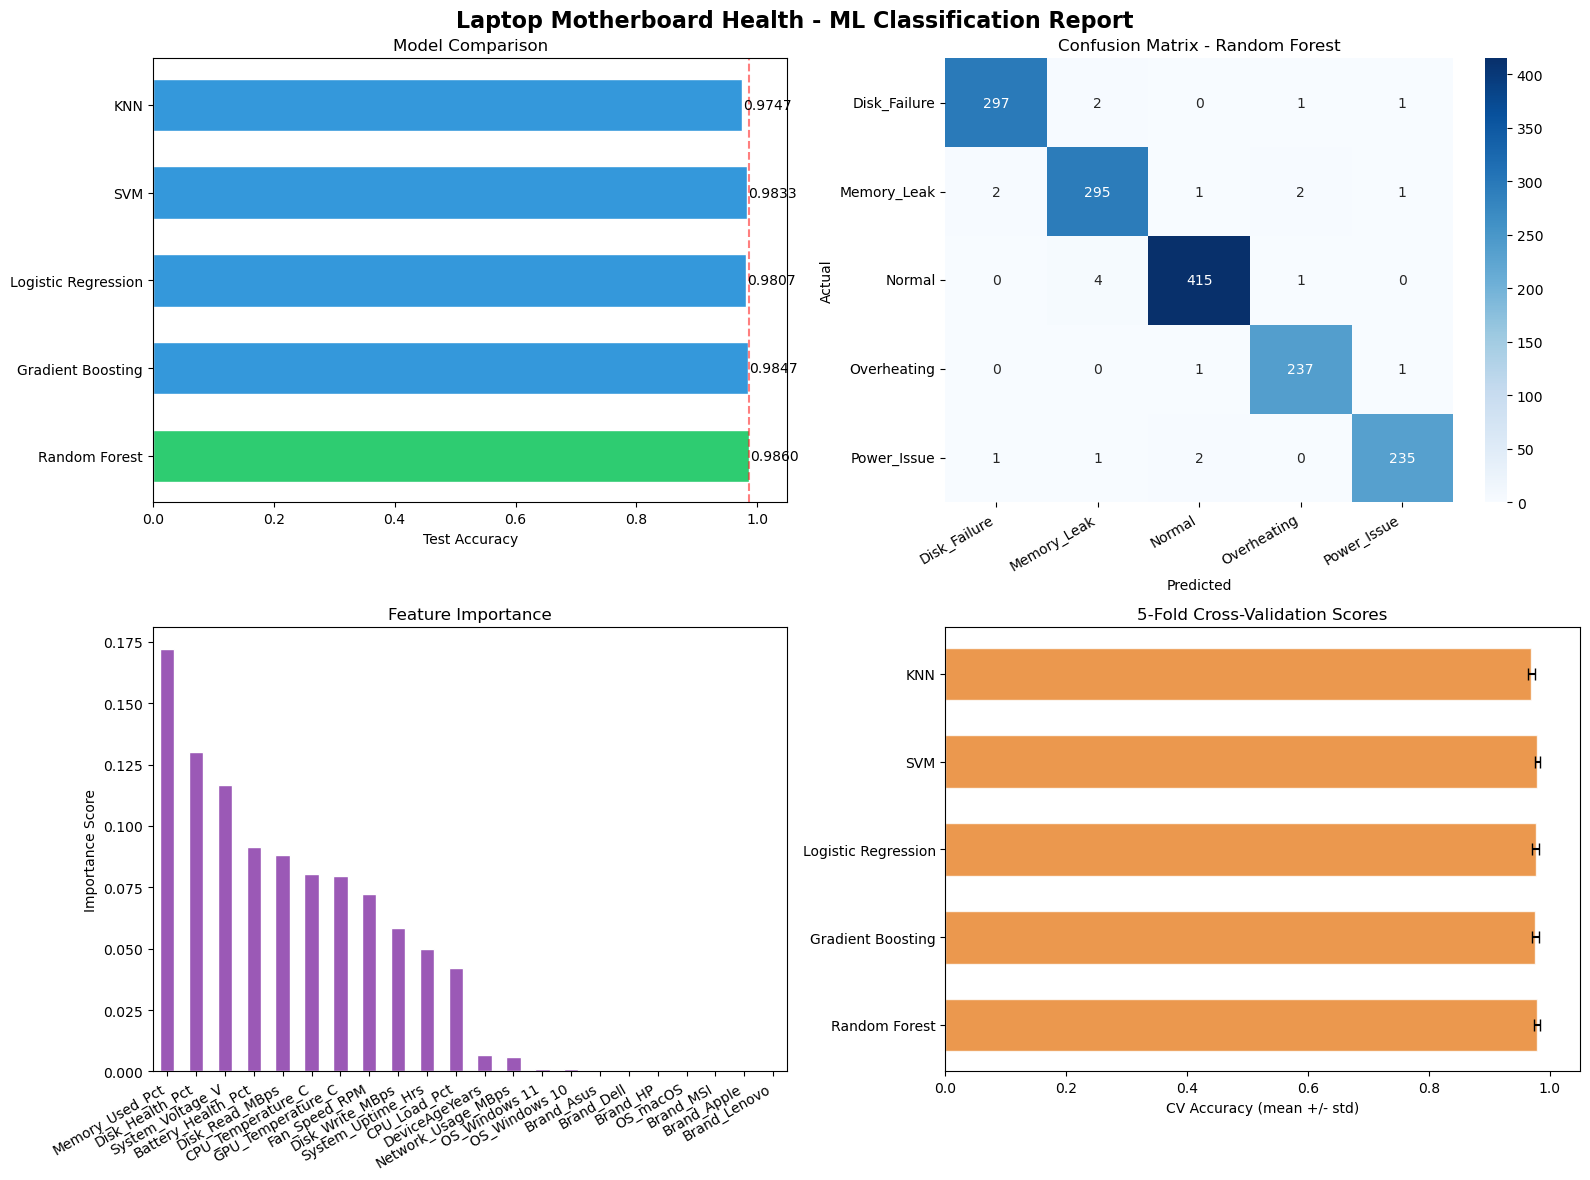

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Laptop Motherboard Health - ML Classification Report', fontsize=16, fontweight='bold')

# Bar Chart
ax = axes[0, 0]
names     = list(results.keys())
test_accs = [results[n]['test_acc'] for n in names]
colors    = ['#2ecc71' if n == best_name else '#3498db' for n in names]
bars = ax.barh(names, test_accs, color=colors, edgecolor='white', height=0.6)
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison')
ax.axvline(x=max(test_accs), color='red', linestyle='--', alpha=0.5)

# Confusion Matrix
ax = axes[0, 1]
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix - {best_name}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Feature Importance
ax = axes[1, 0]
if feat_imp is not None:
    feat_imp.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
    ax.set_title('Feature Importance')
    ax.set_ylabel('Importance Score')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
else:
    ax.text(0.5, 0.5, 'Feature importance not\navailable for this model',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('Feature Importance')

# CV Score Distribution
ax = axes[1, 1]
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds  = [results[n]['cv_std']  for n in names]
ax.barh(names, cv_means, xerr=cv_stds, color='#e67e22', alpha=0.8,
        edgecolor='white', height=0.6, capsize=4)
ax.set_xlim(0, 1.05)
ax.set_xlabel('CV Accuracy (mean +/- std)')
ax.set_title('5-Fold Cross-Validation Scores')

plt.tight_layout()
plt.savefig('ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

Export Best Model

In [12]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'label_encoder': le, 'features': list(X.columns)}, f)
print("Model saved = best_model.pkl")

Model saved = best_model.pkl


Test Sample

In [13]:
sample = X_test.iloc[:3].copy()
preds  = le.inverse_transform(best_model.predict(sample))
actual = le.inverse_transform(y_test[:3])
for i, (pred, act) in enumerate(zip(preds, actual)):
    status = "CORRECT" if pred == act else "WRONG"
    print(f"  Sample {i+1}: Predicted={pred:15s} | Actual={act:15s}  {status}")

print("\nDone!")

  Sample 1: Predicted=Overheating     | Actual=Overheating      CORRECT
  Sample 2: Predicted=Normal          | Actual=Normal           CORRECT
  Sample 3: Predicted=Memory_Leak     | Actual=Memory_Leak      CORRECT

Done!


Convert to JSON

In [ ]:
df = pd.read_csv("dataset.csv")
df.to_json("dataset.json", orient="records", indent=2)